# 方案三_v2：图论反应网络动力学评价

> 基于 McDermott et al., *Nature Communications* 2021
> "A graph-based network for predicting chemical reaction pathways in solid-state materials synthesis"

**核心思路**：用热力学自由能 + Softplus 成本函数替代昂贵的 CI-NEB 势垒计算。
构建加权有向反应图，通过 K-最短路径 + 交叉反应 + 线性组合找到最优合成路径。


## 1. 参数配置


In [1]:
# ===== 方案三_v2：图论反应网络动力学评价 =====
# 基于 McDermott et al., Nature Communications 2021
# 用热力学自由能 + Softplus成本函数替代CI-NEB势垒计算

# ===== 修复 OpenMP 冲突 =====
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# ===== 目标化合物 =====  (ref/输出表格.md 表3: Fe₂SiS₄)
TARGET_FORMULA = "Fe2SiS4"

# ===== 化学体系（用于方案1数据匹配，修改目标时同步修改）=====
system = ["Fe", "Si", "S"]

# ===== 合成温度（影响成本函数映射）=====
T_SYNTHESIS = 1073.0      # K (≈800°C, 典型固相合成温度)

# ===== 中间相热力学过滤（论文推荐 0.03/0.1/0.5 eV/atom）=====
E_ABOVE_HULL_CUTOFF = 0.5   # eV/atom, 较宽松以包含亚稳态中间相和目标
COMPOSITION_WINDOW = False  # 跨体系验证时关闭，让凸包自动确定前驱体

# ===== 手动指定前驱体 =====
USE_MANUAL_PRECURSORS = False
MANUAL_PRECURSORS = ["Fe", "S"]

# ===== 网络构建参数 =====
MAX_REACTANTS = 2        # 最大同时反应相数 n=2 (paper default)
K_SHORTEST = 10          # KSP 路径数

# ===== 交叉反应与线性组合 =====
ENABLE_CROSSOVER = True   # 启用交叉反应+线性组合
CROSSOVER_MAX_PHASES = 12 # 最多考虑多少中间相做交叉反应

# ===== 成本函数参数 =====
# C = ln(1 + exp((T_scale/T_synth) * Δg_rxn))
COST_T_SCALE = 273.0      # 参考温度标度 (K), paper默认273

SUMMARY_STR = f"""
Target: {TARGET_FORMULA}
T_synth: {T_SYNTHESIS} K | Hull cutoff: {E_ABOVE_HULL_CUTOFF} eV/atom
Max reactants: {MAX_REACTANTS} | KSP: {K_SHORTEST} paths
Cost fn: C = ln(1+exp(({COST_T_SCALE}/T) * Δg_rxn))
"""
print(SUMMARY_STR)



Target: Fe2SiS4
T_synth: 1073.0 K | Hull cutoff: 0.5 eV/atom
Max reactants: 2 | KSP: 10 paths
Cost fn: C = ln(1+exp((273.0/T) * Δg_rxn))



## 2. 导入库


In [2]:
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
from mp_api.client import MPRester
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import networkx as nx
from itertools import combinations, product as _product
from math import gcd
from collections import defaultdict, Counter
from time import time

import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

from pymatgen.analysis.phase_diagram import PhaseDiagram
from pymatgen.entries.mixing_scheme import MaterialsProjectDFTMixingScheme
from rxn_network.reactions.computed import ComputedReaction
from scipy.linalg import pinv
from scipy.optimize import nnls

load_dotenv(os.path.join("..", "api", "myapi.env"))
API_KEY = os.getenv("MP_API_KEY")
if not API_KEY: raise ValueError("MP_API_KEY missing")
print("All imports OK, API key loaded")


All imports OK, API key loaded


## 3. MP 数据获取与中间相过滤


In [3]:
import json
from monty.json import MontyDecoder

t0 = time()

# ===== 数据加载优先级：方案2(Gibbs修正) > 方案1(0K) > MP API =====
entries_loaded = False

# --- Priority 1: 方案2 Gibbs 修正条目（温度修正后的能量）---
scheme2_export = os.path.join("..", "方案2", "scheme2_gibbs_export.json")
if os.path.exists(scheme2_export):
    print("📂 检测到方案2 Gibbs导出文件，优先加载温度修正后的条目...")
    try:
        with open(scheme2_export, "r", encoding="utf-8") as f:
            export_data = json.load(f, cls=MontyDecoder)
        exported_system = export_data.get("system", [])
        if set(exported_system) != set(system):
            print(f"⚠️ 方案2体系不匹配，跳过")
        else:
            entries = export_data["entries"]
            T_gibbs = export_data.get("gibbs_temperature_K", 900.0)
            print(f"   从方案2加载 {len(entries)} 条 Gibbs 修正条目 (T={T_gibbs} K, 形成能)")
            # 确保 entry_id 为字符串
            for e in entries:
                if not isinstance(getattr(e, "entry_id", None), str):
                    e.entry_id = str(getattr(e, "entry_id", e.composition.reduced_formula))
            # Gibbs 修正条目不经过 mixing scheme（能量已修正）
            # 从 entries 中定位 target
            target_entry = None
            for e in entries:
                if e.composition.reduced_formula == TARGET_FORMULA:
                    if target_entry is None or e.energy_per_atom < target_entry.energy_per_atom:
                        target_entry = e
            if target_entry is not None:
                target_struct = target_entry.structure
                target_id = getattr(target_entry, "entry_id", "N/A")
                entries_loaded = True
                T_SYNTHESIS = T_gibbs  # 覆盖为 Gibbs 修正温度
                print(f"   T_synthesis 覆盖为: {T_gibbs} K")
    except Exception as e:
        print(f"⚠️ 方案2文件加载失败: {e}")

# --- Priority 2: 方案1 0K 条目（含 MACE-MP-0 预测）---
if not entries_loaded:
    scheme1_export = os.path.join("..", "方案1", "scheme1_export.json")
    if os.path.exists(scheme1_export):
        print("📂 检测到方案1导出文件，从本地加载...")
        try:
            with open(scheme1_export, "r", encoding="utf-8") as f:
                export_data = json.load(f, cls=MontyDecoder)
            exported_system = export_data.get("system", [])
            if set(exported_system) != set(system):
                print(f"⚠️ 体系不匹配 (导出: {exported_system}, 当前: {system})，改从 MP 获取")
            else:
                entries = export_data["entries"]
                n_mp_s1 = export_data.get("n_entries_mp", "?")
                n_ml_s1 = export_data.get("n_entries_mace", export_data.get("n_entries_m3gnet", "?"))
                print(f"   从方案1加载 {len(entries)} 条条目")
                print(f"   (MP: {n_mp_s1}, MACE-MP-0: {n_ml_s1})")
                for e in entries:
                    if not isinstance(getattr(e, "entry_id", None), str):
                        e.entry_id = str(getattr(e, "entry_id", e.composition.reduced_formula))
                for e in entries:
                    if getattr(e, "data", {}).get("source", "") in ("M3GNet", "MACE-MP-0"):
                        if not hasattr(e, "parameters") or e.parameters is None:
                            e.parameters = {}
                        e.parameters.setdefault("run_type", "M3GNet")
                target_entry = None
                for e in entries:
                    if e.composition.reduced_formula == TARGET_FORMULA:
                        if target_entry is None or e.energy_per_atom < target_entry.energy_per_atom:
                            target_entry = e
                if target_entry is None:
                    raise ValueError(f"Target {TARGET_FORMULA} not found in loaded entries")
                target_struct = target_entry.structure
                target_id = getattr(target_entry, "entry_id", "N/A")
                # 仅 MP 条目过 mixing scheme
                entries_mp = [e for e in entries if getattr(e, "data", {}).get("source", "") not in ("M3GNet", "MACE-MP-0")]
                entries_ml = [e for e in entries if getattr(e, "data", {}).get("source", "") in ("M3GNet", "MACE-MP-0")]
                scheme = MaterialsProjectDFTMixingScheme()
                entries_mp = scheme.process_entries(entries_mp)
                entries = entries_mp + entries_ml
                entries_loaded = True
        except Exception as e:
            print(f"⚠️ 方案1文件加载失败: {e}，改从 MP 获取")
            import traceback
            traceback.print_exc()

# --- Priority 3: MP API 直接获取 ---
if not entries_loaded:
    print("🌐 从 Materials Project 数据库获取条目...")
    with MPRester(API_KEY) as mpr:
        docs = mpr.materials.summary.search(formula=TARGET_FORMULA,
            fields=["material_id","structure","energy_above_hull"])
        docs = sorted([d for d in docs if d.energy_above_hull is not None],
                      key=lambda x: x.energy_above_hull)
        target_struct = docs[0].structure
        target_id = docs[0].material_id
        print(f"Target: {target_struct.composition.reduced_formula} ({target_id})")
        print(f"  e_above_hull = {docs[0].energy_above_hull:.4f} eV/atom")
        entries = mpr.get_entries_in_chemsys(system, include_structure=True,
            additional_criteria={"thermo_types": ["GGA_GGA+U"]})
        scheme = MaterialsProjectDFTMixingScheme()
        entries = scheme.process_entries(entries)
        print(f"Chemical system: {system}, {len(entries)} MP entries")
        entries_loaded = True

els = [str(el) for el in target_struct.composition.elements]
print(f"Chemical system: {els}, {len(entries)} entries total")

# ===== Phase filtering by energy above hull =====
pd_0k = PhaseDiagram(entries)
filtered = []
for e in entries:
    hull_e = pd_0k.get_e_above_hull(e)
    if hull_e is not None and hull_e < E_ABOVE_HULL_CUTOFF:
        e.data["e_above_hull"] = hull_e
        filtered.append(e)

# ---- Always ensure target is in filtered (even if above hull cutoff) ----
target_in_filtered = any(e.composition.reduced_formula == TARGET_FORMULA for e in filtered)
if not target_in_filtered:
    target_entries_full = [e for e in entries if e.composition.reduced_formula == TARGET_FORMULA]
    if target_entries_full:
        best_target = min(target_entries_full, key=lambda e: e.energy_per_atom)
        hull_t = pd_0k.get_e_above_hull(best_target)
        best_target.data["e_above_hull"] = hull_t if hull_t is not None else 999
        filtered.append(best_target)
        print(f"  (target {TARGET_FORMULA} forced into filtered, e_hull={hull_t:.4f})")

formulas_full = sorted(set(e.composition.reduced_formula for e in filtered))
print(f"\nAfter hull filter (< {E_ABOVE_HULL_CUTOFF} eV/atom): {len(filtered)} entries, {len(formulas_full)} phases")
print(f"Phases: {formulas_full}")

# ---- Keep only ground-state polymorph per formula ----
ground_state = {}
for e in filtered:
    rf = e.composition.reduced_formula
    if rf not in ground_state or e.energy_per_atom < ground_state[rf].energy_per_atom:
        ground_state[rf] = e
filtered = list(ground_state.values())
formulas_full = sorted(ground_state.keys())
print(f"After polymorph dedup: {len(filtered)} ground-state entries, {len(formulas_full)} phases")

# ---- Build entry_map for fast lookup ----
entry_map = {}
for e in filtered:
    entry_map[e.composition.reduced_formula] = e

# ---- Determine precursors ----
target_comp = target_struct.composition
decomp = pd_0k.get_decomposition(target_comp)
if len(decomp) <= 1:
    target_entries_local = [e for e in entries if e.composition.reduced_formula == target_comp.reduced_formula]
    entries_no_target = [e for e in entries if e not in target_entries_local]
    decomp = PhaseDiagram(entries_no_target).get_decomposition(target_comp)

if USE_MANUAL_PRECURSORS:
    PRECURSOR_FORMULAS = MANUAL_PRECURSORS
    print(f"Precursors (manual): {PRECURSOR_FORMULAS}")
else:
    PRECURSOR_FORMULAS = [pd_e.composition.reduced_formula for pd_e in decomp.keys()]
    print(f"Precursors (auto): {PRECURSOR_FORMULAS}")

# ---- Composition window (optional) ----
if COMPOSITION_WINDOW:
    ref_formulas = PRECURSOR_FORMULAS + [TARGET_FORMULA]
    elem_range = {}
    for rf in ref_formulas:
        comp = target_struct.composition if rf == TARGET_FORMULA else None
        if comp is None:
            if rf in entry_map:
                comp = entry_map[rf].composition
        if comp is None: continue
        for el, amt in comp.element_composition.items():
            frac = amt / comp.num_atoms
            lo, hi = elem_range.get(el, [frac, frac])
            elem_range[el] = [min(lo, frac), max(hi, frac)]
    windowed = []
    for e in filtered:
        ok = True
        for el, amt in e.composition.element_composition.items():
            frac = amt / e.composition.num_atoms
            lo, hi = elem_range.get(el, [0.0, 1.0])
            if frac < lo - 0.05 or frac > hi + 0.05:
                ok = False; break
        if ok: windowed.append(e)
    n_removed = len(filtered) - len(windowed)
    filtered = windowed
    formulas_full = sorted(set(e.composition.reduced_formula for e in filtered))
    if n_removed > 0:
        print(f"Composition window removed {n_removed} phases")
        print(f"After window filter: {len(filtered)} entries, {len(formulas_full)} phases")

print(f"\nSetup done in {time()-t0:.0f}s")


📂 检测到方案2 Gibbs导出文件，优先加载温度修正后的条目...
   从方案2加载 143 条 Gibbs 修正条目 (T=900.0 K, 形成能)
   T_synthesis 覆盖为: 900.0 K
Chemical system: ['Fe', 'Si', 'S'], 143 entries total
  (target Fe2SiS4 forced into filtered, e_hull=7.5234)

After hull filter (< 0.5 eV/atom): 111 entries, 20 phases
Phases: ['Fe', 'Fe11Si5', 'Fe2Si', 'Fe2Si5', 'Fe2SiS4', 'Fe3S', 'Fe3S4', 'Fe3Si', 'Fe4S5', 'Fe4Si', 'Fe5Si3', 'FeS', 'FeS2', 'FeSi2', 'FeSiS2', 'S', 'Si', 'SiS', 'SiS2', 'SiS4']
After polymorph dedup: 20 ground-state entries, 20 phases
Precursors (auto): ['FeS2', 'FeSiS2']

Setup done in 0s


## 4. 反应网络构建


**节点**：所有不超过 `MAX_REACTANTS` 种的相组合（frozenset of formulas）

**边**：两节点间可化学计量配平的反应。排除恒等反应。


In [4]:
def enumerate_reactions(entries, max_reactants=2, verbose=True):
    """枚举所有可化学计量配平的反应对"""
    entry_list = list(entries)
    combos = []
    for n in range(1, max_reactants + 1):
        for combo in combinations(entry_list, n):
            combos.append(set(combo))
    if verbose:
        print(f"Phase combinations: {len(combos)}")
    reactions = []
    for i in range(len(combos)):
        for j in range(i + 1, len(combos)):
            if combos[i] & combos[j]:
                continue  # 不能有重叠相
            try:
                rxn = ComputedReaction.balance(list(combos[i]), list(combos[j]))
                if not rxn.is_identity:
                    reactions.append(rxn)
                    reactions.append(rxn.reverse())
            except Exception:
                pass
    if verbose:
        print(f"Raw reactions: {len(reactions)}")
    return reactions

def deduplicate_by_formula(reactions):
    """按化学式去重"""
    seen = {}
    unique = []
    for rxn in reactions:
        r_key = frozenset(e.composition.reduced_formula for e in rxn.reactant_entries)
        p_key = frozenset(e.composition.reduced_formula for e in rxn.product_entries)
        key = (r_key, p_key)
        if key not in seen:
            seen[key] = rxn
            unique.append(rxn)
    return unique

# ---- Enumerate and filter ----
rxns_raw = enumerate_reactions(filtered, MAX_REACTANTS)
rxns_unique = deduplicate_by_formula(rxns_raw)
print(f"After dedup: {len(rxns_unique)} unique reaction edges")

# ---- Only keep reactions involving precursors or target ----
precursor_set = frozenset(PRECURSOR_FORMULAS)
rxns_filtered = []
for rxn in rxns_unique:
    r_fs = frozenset(e.composition.reduced_formula for e in rxn.reactant_entries)
    p_fs = frozenset(e.composition.reduced_formula for e in rxn.product_entries)
    if (r_fs & precursor_set) or (TARGET_FORMULA in p_fs) or (TARGET_FORMULA in r_fs):
        rxns_filtered.append(rxn)
rxns_unique = rxns_filtered
print(f"After precursor/target proximity filter: {len(rxns_unique)} edges")

N_EDGES = len(rxns_unique)
print(f"\nReaction network: {len(formulas_full)} phases → {N_EDGES} unique reaction edges")


Phase combinations: 210
Raw reactions: 29904
After dedup: 12652 unique reaction edges
After precursor/target proximity filter: 4285 edges

Reaction network: 20 phases → 4285 unique reaction edges


## 5. Softplus 热力学成本函数


**核心公式** (rxn_network costs/functions.py:77):

$$C = \\ln\\left(1 + \\frac{273}{T} \\cdot e^{\\Delta g_{\\text{rxn}}}\\right)$$

其中：
- $T$ = 合成温度 (K)
- $\\Delta g_{\\text{rxn}} =$ `rxn.energy_per_atom`（反应自由能，eV/atom）

**特性**：
- $\\Delta g \\ll 0$（强放热）→ $C \\to 0$
- $\\Delta g > 0$（吸热）→ $C$ 近似 $\\Delta g + \\ln(273/T)$


In [5]:
# ===== 直接使用 rxn.energy_per_atom（官方 Softplus 的默认参数）=====
# 参考: rxn_network/costs/functions.py: Softplus.evaluate()

def softplus_cost(energy_per_atom, T=1073.0):
    """官方 Softplus: C = ln(1 + (273/T) * exp(energy_per_atom))
    参考 rxn_network/src/rxn_network/costs/functions.py line 77
    """
    return float(np.log1p((273.0 / T) * np.exp(energy_per_atom)))


# ===== Compute costs for all edges =====
print("Computing thermodynamic costs for all edges...")
edge_costs = {}  # (r_key, p_key) -> (cost, dg)
for rxn in rxns_unique:
    r_key = frozenset(e.composition.reduced_formula for e in rxn.reactant_entries)
    p_key = frozenset(e.composition.reduced_formula for e in rxn.product_entries)
    dg = rxn.energy_per_atom  # ← 官方做法：直接用 energy_per_atom
    cost = softplus_cost(dg, T=T_SYNTHESIS)
    edge_costs[(r_key, p_key)] = (cost, dg)

print(f"Computed costs for {len(edge_costs)} edges")

# ===== Cost statistics =====
costs_list = [c for c, _ in edge_costs.values()]
dgs_list = [d for _, d in edge_costs.values()]
print(f"\nCost statistics:")
print(f"  Δg_rxn range: {min(dgs_list):.4f} ~ {max(dgs_list):.4f} eV/atom")
print(f"  Cost range:   {min(costs_list):.4f} ~ {max(costs_list):.4f}")

# ===== Show top-10 most favorable edges =====
print(f"\nTop-10 most thermodynamically favorable edges:")
sorted_edges = sorted(edge_costs.items(), key=lambda x: x[1][0])
for rank, ((rk, pk), (cost, dg)) in enumerate(sorted_edges[:10]):
    rs = "+".join(sorted(rk))
    ps = "+".join(sorted(pk))
    print(f"  {rank+1}. C={cost:.4f} Δg={dg:+.4f} eV/atom | {rs} → {ps}")


Computing thermodynamic costs for all edges...
Computed costs for 4285 edges

Cost statistics:
  Δg_rxn range: -12.7736 ~ 13.4540 eV/atom
  Cost range:   0.0000 ~ 12.2611

Top-10 most thermodynamically favorable edges:
  1. C=0.0000 Δg=-12.7736 eV/atom | Fe2Si5+Fe2SiS4+S → FeSiS2
  2. C=0.0000 Δg=-12.6947 eV/atom | Fe+Fe2SiS4+SiS → FeSiS2
  3. C=0.0000 Δg=-12.6875 eV/atom | Fe2SiS4+FeSi2+S → FeSiS2
  4. C=0.0000 Δg=-12.6831 eV/atom | Fe2SiS4+Fe3S+SiS → FeSiS2
  5. C=0.0000 Δg=-12.6628 eV/atom | Fe2SiS4+Fe5Si3+SiS4 → FeSiS2
  6. C=0.0000 Δg=-12.6471 eV/atom | Fe2SiS4+Si → FeSiS2+S
  7. C=0.0000 Δg=-12.6471 eV/atom | Fe2Si5+Fe2SiS4+Si → FeSiS2
  8. C=0.0000 Δg=-12.6471 eV/atom | Fe2SiS4+Fe4S5+Si → FeSiS2
  9. C=0.0000 Δg=-12.6471 eV/atom | Fe2SiS4+Fe3S4+Si → FeSiS2
  10. C=0.0000 Δg=-12.6471 eV/atom | Fe2SiS4+Si+SiS → FeSiS2


## 6. 图构建：循环边与外部节点


**零成本循环边**：允许生成的中间产物继续参与后续反应，从而捕获多步反应序列。

**外部节点**：
- **SOURCE**：零成本连接到所有前驱体可及的反应物节点
- **SINK**：所有包含目标产物的节点以零成本连接到汇点


In [6]:
def build_thermo_graph(rxns, edge_costs):
    """构建热力学加权有向反应图 (对标 ReactionNetwork.build)
    - 两类节点: Rx (反应物) 和 Pd (产物)
    - 循环边: Pd → 同组合的 Rx (官方 get_loopback_edges)
    """
    G = nx.DiGraph()
    r_nodes = {}  # frozenset -> idx
    p_nodes = {}
    for rxn in rxns:
        r_key = frozenset(e.composition.reduced_formula for e in rxn.reactant_entries)
        p_key = frozenset(e.composition.reduced_formula for e in rxn.product_entries)
        if r_key not in r_nodes:
            idx = len(G.nodes())
            G.add_node(idx, ntype="Rx", formulas=r_key, label="+".join(sorted(r_key)))
            r_nodes[r_key] = idx
        if p_key not in p_nodes:
            idx = len(G.nodes())
            G.add_node(idx, ntype="Pd", formulas=p_key, label="+".join(sorted(p_key)))
            p_nodes[p_key] = idx
        cost, dg = edge_costs.get((r_key, p_key), (10.0, 10.0))
        G.add_edge(r_nodes[r_key], p_nodes[p_key], edge_type="reaction", reaction=rxn, cost=cost, dg=dg)
    # Loopback: product -> same-combo reactant
    lb = 0
    for key in set(r_nodes) & set(p_nodes):
        if not G.has_edge(p_nodes[key], r_nodes[key]):
            G.add_edge(p_nodes[key], r_nodes[key], edge_type="loopback", cost=0.0, dg=0.0)
            lb += 1
    print(f"Graph: {G.number_of_nodes()} nodes ({len(r_nodes)}Rx,{len(p_nodes)}Pd), {G.number_of_edges()} edges ({len(rxns)}rxn+{lb}lb)")
    return G, r_nodes, p_nodes


def add_source_sink(G, r_nodes, p_nodes, source_formulas, target_formula):
    """SOURCE->Rx(subset precursors), Pd(含target)->SINK"""
    SOURCE, SINK = -1, -2
    G.add_node(SOURCE, ntype="Source", label="SOURCE")
    G.add_node(SINK, ntype="Sink", label="SINK")
    sc = set(source_formulas)
    src = snk = 0
    for r_key, r_idx in r_nodes.items():
        if r_key.issubset(sc):
            G.add_edge(SOURCE, r_idx, edge_type="precursor_edge", cost=0.0, dg=0.0)
            src += 1
    for p_key, p_idx in p_nodes.items():
        if target_formula in p_key:
            G.add_edge(p_idx, SINK, edge_type="target_edge", cost=0.0, dg=0.0)
            snk += 1
    print(f"  Source→{src}Rx, {snk}Pd→Sink")
    return SOURCE, SINK


# ===== Build graph =====
G, r_nodes, p_nodes = build_thermo_graph(rxns_unique, edge_costs)
SOURCE, SINK = add_source_sink(G, r_nodes, p_nodes, PRECURSOR_FORMULAS, TARGET_FORMULA)
print(f"Total: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Graph: 1189 nodes (587Rx,602Pd), 4774 edges (4285rxn+489lb)
  Source→3Rx, 97Pd→Sink
Total: 1191 nodes, 4874 edges


## 7. K-最短路径搜索（Yen 算法）


使用 Yen's KSP 算法从前驱体节点到目标节点搜索前 K 条最短路径（按累积成本排序）。


In [7]:
def yen_ksp(G, source, target, K=10):
    """Yen's K-Shortest Paths 算法

    在加权有向图中找到从 source 到 target 的前 K 条最短路径。
    返回：[(total_cost, node_path), ...]
    """
    try:
        fp = nx.shortest_path(G, source, target, weight="cost")
        fc = sum(G[fp[i]][fp[i+1]]["cost"] for i in range(len(fp)-1))
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return []
    A = [(fc, fp)]
    B = []
    for k in range(1, K):
        prev = A[-1][1]
        for i in range(len(prev) - 1):
            spur = prev[i]
            root = prev[:i+1]
            Gc = G.copy()
            for _, pv in A:
                if len(pv) > i + 1 and pv[:i+1] == root:
                    u, v = pv[i], pv[i+1]
                    if Gc.has_edge(u, v): Gc.remove_edge(u, v)
            for node in root[:-1]:
                if node != spur and node >= 0:
                    Gc.remove_node(node)
            try:
                sp = nx.shortest_path(Gc, spur, target, weight="cost")
                tp = root[:-1] + sp
                tc = sum(G[tp[j]][tp[j+1]]["cost"] for j in range(len(tp)-1)
                        if G.has_edge(tp[j], tp[j+1]))
                if tc > 0: B.append((tc, tp))
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                pass
        if not B: break
        B.sort(key=lambda x: x[0])
        found = False; new_B = []
        for cv, pv in B:
            if pv not in [p for _, p in A]:
                A.append((cv, pv)); found = True
            else: new_B.append((cv, pv))
        B = new_B
        if not found: break
    return A


def extract_pathway(G, node_path):
    """从路径中提取反应步骤、成本、Δg 列表（仅真实反应边）"""
    rxns, costs, dgs = [], [], []
    for i in range(len(node_path) - 1):
        edge = G[node_path[i]][node_path[i+1]]
        rxn = edge.get("reaction")
        if rxn is not None and not isinstance(rxn, str):
            rxns.append(rxn)
            costs.append(edge.get("cost", 0))      # 只收集真实反应
            dgs.append(edge.get("dg", 0))          # 与 rxns 对齐
    return rxns, costs, dgs


# ===== Run Yen KSP =====
ksp_paths_raw = yen_ksp(G, SOURCE, SINK, K=K_SHORTEST)
# Filter out trivial cycle-only paths (zero-cost shortcuts with no real reactions)
ksp_paths = [(tc, p) for tc, p in ksp_paths_raw if len(extract_pathway(G, p)[0]) > 0]
print(f"KSP: {len(ksp_paths)} synthesis paths found (filtered from {len(ksp_paths_raw)} raw)\
")

# ===== Display synthesis pathways as markdown table =====
# Table header
print("| 路径 | 总成本 | 步骤 | 反应方程式 | ΔG (eV/atom) | 步骤成本 |")
print("| :---: | :---: | :---: | :--- | :---: | :---: |")
for rank, (tc, path) in enumerate(ksp_paths[:5]):
    rxns_p, costs_p, dgs_p = extract_pathway(G, path)
    for j, rxn in enumerate(rxns_p):
        rk = frozenset(e.composition.reduced_formula for e in rxn.reactant_entries)
        pk = frozenset(e.composition.reduced_formula for e in rxn.product_entries)
        # 表格行：路径 | 总成本 | 步骤 | 反应式 | ΔG | 步骤成本
        print(f"| {rank+1} | {tc:.3f} | {j+1} | {rxn} | {dgs_p[j]:+.3f} | {costs_p[j]:.3f} |")
    # 表格结束后打印空行


KSP: 46 synthesis paths found (filtered from 46 raw)
| 路径 | 总成本 | 步骤 | 反应方程式 | ΔG (eV/atom) | 步骤成本 |
| :---: | :---: | :---: | :--- | :---: | :---: |
| 1 | 0.425 | 1 | FeS2 -> 0.6667 S + 0.3333 Fe3S4 | +0.556 | 0.425 |
| 2 | 0.580 | 1 | FeS2 -> 0.6667 S + 0.3333 Fe3S4 | +0.556 | 0.425 |
| 2 | 0.580 | 2 | 3.556 S + 0.1111 Fe3S4 + 0.3333 Fe5Si3 -> Fe2SiS4 | -0.588 | 0.156 |
| 3 | 0.585 | 1 | 3 FeS2 -> 2 S + Fe3S4 | +0.556 | 0.425 |
| 3 | 0.585 | 2 | 2 S + Fe3S4 -> 3 FeS2 | -0.556 | 0.160 |
| 4 | 0.703 | 1 | 4 FeS2 -> 3 S + Fe4S5 | +0.987 | 0.595 |
| 4 | 0.703 | 2 | 3 S + Fe4S5 -> 4 FeS2 | -0.987 | 0.107 |
| 5 | 1.058 | 1 | 3 FeS2 -> 2 S + Fe3S4 | +0.556 | 0.425 |
| 5 | 1.058 | 2 | 2 S + Fe3S4 -> 3 FeS2 | -0.556 | 0.160 |
| 5 | 1.058 | 3 | FeS2 + 1.5 Fe2SiS4 -> Fe4S5 + 1.5 SiS2 | +0.007 | 0.267 |
| 5 | 1.058 | 4 | Fe4S5 + 0.5 SiS2 -> Fe3S4 + 0.5 Fe2SiS4 | -0.278 | 0.207 |


## 8. 交叉反应与线性组合


**交叉反应**（Crossover Reactions）：从 KSP 路径中提取中间相，枚举它们之间所有能生成目标产物的反应。

**线性组合**：将所有交叉反应按化学计量线性组合，求解满足总反应（前驱体 → 目标）的最优反应倍数。
总成本 = $\frac{\sum m_i \cdot C_i}{\sum m_i}$（加权平均）。


In [8]:
def extract_intermediate_phases(ksp_paths, G, top_k=3):
    """从KSP前top_k路径中提取中间相（单相）"""
    intermediates = set()
    for _, path in ksp_paths[:top_k]:
        for node in path:
            if node >= 0:
                formulas = G.nodes[node].get('formulas', set())
                for f in formulas:
                    if f != TARGET_FORMULA and f not in PRECURSOR_FORMULAS:
                        intermediates.add(f)
    return intermediates


def compute_crossover_reactions(filtered_entries, entry_map, precursors, target, intermediates):
    """计算交叉反应：用中间相+前驱体生成目标产物的所有可能反应"""
    candidate_formulas = set(precursors) | intermediates
    candidate_formulas.discard(target)
    candidate_entries = [entry_map[f] for f in candidate_formulas if f in entry_map]
    target_entry = entry_map.get(target)
    if target_entry is None or len(candidate_entries) < 1:
        return []

    # Build all 1- and 2-phase combinations as reactants
    combos = []
    # Single-phase reactants
    for e in candidate_entries:
        combos.append(set([e]))
    # Two-phase combinations
    for combo in combinations(candidate_entries, 2):
        combos.append(set(combo))

    crossover_rxns = []
    for reactant_set in combos:
        # Try: reactants → target only
        try:
            rxn = ComputedReaction.balance(list(reactant_set), [target_entry])
            if not rxn.is_identity:
                crossover_rxns.append(rxn)
        except Exception:
            pass
        # Try: reactants → target + other phases
        # Use all entries as possible co-products
        for other_set in combos:
            if reactant_set & other_set:
                continue
            try:
                products = [target_entry] + [e for e in other_set
                    if e.composition.reduced_formula != target]
                rxn = ComputedReaction.balance(list(reactant_set), products)
                if not rxn.is_identity:
                    crossover_rxns.append(rxn)
            except Exception:
                pass

    # Deduplicate
    seen = set()
    unique_rxns = []
    for rxn in crossover_rxns:
        rk = frozenset(e.composition.reduced_formula for e in rxn.reactant_entries)
        pk = frozenset(e.composition.reduced_formula for e in rxn.product_entries)
        key = (rk, pk)
        if key not in seen:
            seen.add(key)
            unique_rxns.append(rxn)
    return unique_rxns


if ENABLE_CROSSOVER:
    # 从 KSP 路径提取中间相（若有）；否则用全部非前驱体/非目标相
    if len(ksp_paths) > 0:
        print("--- Extracting intermediates from top KSP paths ---")
        intermediates = extract_intermediate_phases(ksp_paths, G, top_k=3)
    else:
        print("--- KSP empty, using all non-precursor/target phases as intermediates ---")
        intermediates = set(formulas_full) - set(PRECURSOR_FORMULAS) - {TARGET_FORMULA}
    print(f"Intermediate phases: {sorted(intermediates) if intermediates else '(none)'}")

    print(f"\n--- Computing crossover reactions ---")
    crossover_rxns = compute_crossover_reactions(
        filtered, entry_map, PRECURSOR_FORMULAS, TARGET_FORMULA, intermediates)
    print(f"Crossover reactions: {len(crossover_rxns)}")

    if crossover_rxns:
        # Compute costs for crossover reactions
        crossover_edge_costs = {}
        for rxn in crossover_rxns:
            rk = frozenset(e.composition.reduced_formula for e in rxn.reactant_entries)
            pk = frozenset(e.composition.reduced_formula for e in rxn.product_entries)
            dg = rxn.energy_per_atom
            cost = softplus_cost(dg, T=T_SYNTHESIS)
            crossover_edge_costs[(rk, pk)] = (cost, dg, rxn)

        # Show top crossover reactions by cost
        print(f"\nTop crossover reactions (by cost):")
        sorted_cross = sorted(crossover_edge_costs.items(), key=lambda x: x[1][0])
        for rank, ((rk, pk), (cost, dg, rxn)) in enumerate(sorted_cross[:15]):
            rs = "+".join(sorted(rk))
            ps = "+".join(sorted(pk))
            print(f"  {rank+1}. C={cost:.4f} Δg={dg:+.4f} | {rs} → {ps}")

        print(f"\n--- Linear combination (pseudo-inverse) ---")
        # Build total reaction: precursors → target
        precursor_entries = [entry_map[f] for f in PRECURSOR_FORMULAS if f in entry_map]
        target_entry = entry_map.get(TARGET_FORMULA)

        if target_entry and len(precursor_entries) == len(PRECURSOR_FORMULAS):
            total_rxn = ComputedReaction.balance(precursor_entries, [target_entry])
            if not total_rxn.is_identity:
                print(f"Total reaction: {total_rxn}")
                # Build total stoichiometry dict
                total_stoich = {}
                all_ents2 = tuple(total_rxn.reactant_entries) + tuple(total_rxn.product_entries)
                for coeff, entry in zip(total_rxn.coefficients, all_ents2):
                    rf = entry.composition.reduced_formula
                    total_stoich[rf] = total_stoich.get(rf, 0) + coeff

                # Collect all phases involved in crossover reactions
                all_phases = set(total_stoich.keys())
                for (rk, pk) in crossover_edge_costs:
                    all_phases.update(rk); all_phases.update(pk)
                all_phases = sorted(all_phases)
                phase_idx = {p: i for i, p in enumerate(all_phases)}

                # Build target vector c and matrix A
                n_phases = len(all_phases)
                c = np.zeros(n_phases)
                for formula, coeff in total_stoich.items():
                    c[phase_idx[formula]] = coeff

                cross_list = list(crossover_edge_costs.items())
                A = np.zeros((n_phases, len(cross_list)))
                for j, ((rk, pk), (cost, dg, rxn)) in enumerate(cross_list):
                    all_ents3 = tuple(rxn.reactant_entries) + tuple(rxn.product_entries)
                    for coeff, entry in zip(rxn.coefficients, all_ents3):
                        rf = entry.composition.reduced_formula
                        A[phase_idx[rf], j] += coeff

                from itertools import combinations as _combos
                MAX_COMBO = 4
                TOLERANCE = 1e-6
                balanced_paths = []
                for n in range(1, MAX_COMBO + 1):
                    for combo in _combos(range(len(cross_list)), n):
                        A_sub = A[:, list(combo)]
                        if A_sub.shape[1] > A_sub.shape[0]:
                            continue
                        try:
                            m_sub = np.linalg.lstsq(A_sub, c, rcond=None)[0]
                        except np.linalg.LinAlgError:
                            continue
                        if np.any(m_sub < -TOLERANCE):
                            continue
                        residual = np.linalg.norm(A_sub @ m_sub - c)
                        if residual > 0.01:
                            continue
                        costs_sub = np.array([cross_list[j][1][0] for j in combo])
                        total_m = np.sum(m_sub)
                        if total_m < TOLERANCE:
                            continue
                        wc = np.sum(m_sub * costs_sub) / total_m
                        balanced_paths.append((m_sub, list(combo), wc, residual))
                if balanced_paths:
                    balanced_paths.sort(key=lambda x: x[2])
                    print(f"  Found {len(balanced_paths)} balanced combinations\n")
                    for pi, (m_sub, combo, wc, res) in enumerate(balanced_paths[:5]):
                        print(f"  --- Path {pi+1} (cost={wc:.4f}, res={res:.6f}, {len(combo)} rxn) ---")
                        for j, (idx, mj) in enumerate(zip(combo, m_sub)):
                            (rk, pk), (cost, dg, rxn) = cross_list[idx]
                            print(f"    {j+1}. x{mj:.3f}  C={cost:.4f} dg={dg:+.3f} | {rxn}")
                        print()
                else:
                    print("  No balanced combination found")
        else:
            print("Cannot balance total reaction: precursor/target entry not found")
else:
    print("Crossover + linear combination SKIPPED")


--- Extracting intermediates from top KSP paths ---
Intermediate phases: ['Fe3S4', 'Fe5Si3', 'S']

--- Computing crossover reactions ---
Crossover reactions: 36

Top crossover reactions (by cost):
  1. C=0.0001 Δg=-8.3663 | Fe2SiS4+Fe5Si3 → Fe3S4+FeSiS2
  2. C=0.0002 Δg=-7.5234 | Fe2SiS4 → FeS2+FeSiS2+S
  3. C=0.0002 Δg=-7.5234 | Fe2SiS4+Fe3S4 → FeS2+FeSiS2
  4. C=0.0002 Δg=-7.5234 | Fe2SiS4 → Fe5Si3+FeS2+FeSiS2
  5. C=0.0005 Δg=-6.4445 | Fe5Si3+S → Fe2SiS4+FeS2+FeSiS2
  6. C=0.0020 Δg=-5.0283 | Fe5Si3+S → Fe2SiS4+Fe3S4+FeSiS2
  7. C=0.0090 Δg=-3.5187 | Fe5Si3+S → Fe2SiS4+FeSiS2
  8. C=0.0829 Δg=-1.2551 | Fe5Si3+FeS2 → Fe2SiS4+Fe3S4+FeSiS2
  9. C=0.1558 Δg=-0.5877 | Fe3S4+Fe5Si3+S → Fe2SiS4
  10. C=0.1571 Δg=-0.5782 | Fe3S4+Fe5Si3+S → Fe2SiS4+FeS2
  11. C=0.1604 Δg=-0.5562 | Fe2SiS4+Fe3S4+S → FeS2
  12. C=0.1676 Δg=-0.5082 | Fe5Si3+FeS2+S → Fe2SiS4
  13. C=0.2109 Δg=-0.2564 | Fe2SiS4+Fe3S4 → Fe5Si3+FeS2
  14. C=0.2900 Δg=+0.1034 | Fe5Si3+FeS2+S → Fe2SiS4+Fe3S4
  15. C=0.3307 Δg=+0.2564

## 9. 分解反应路径


逆方向：从目标产物出发，搜索分解为前驱体相的路径，评估材料的热力学分解倾向。


In [9]:
# ===== Build reverse graph (decomposition) =====
G_dec = G.copy()
for old in [-1, -2]:
    if old in G_dec.nodes():
        G_dec.remove_node(old)
SOURCE_DEC, SINK_DEC = -1, -2
G_dec.add_node(SOURCE_DEC, ntype="Source", label="SOURCE_DEC")
G_dec.add_node(SINK_DEC, ntype="Sink", label="SINK_DEC")
src_dec = snk_dec = 0
pset = set(PRECURSOR_FORMULAS)
for r_key, r_idx in r_nodes.items():
    if TARGET_FORMULA in r_key:
        G_dec.add_edge(SOURCE_DEC, r_idx, edge_type="precursor_edge", cost=0.0, dg=0.0)
        src_dec += 1
for p_key, p_idx in p_nodes.items():
    if p_key.issubset(pset):
        G_dec.add_edge(p_idx, SINK_DEC, edge_type="target_edge", cost=0.0, dg=0.0)
        snk_dec += 1
print(f"Decomposition: Target→{src_dec}Rx, {snk_dec}Pd→Precursors")

# ===== KSP for decomposition =====
ksp_dec_raw = yen_ksp(G_dec, SOURCE_DEC, SINK_DEC, K=K_SHORTEST)
ksp_dec = [(tc, p) for tc, p in ksp_dec_raw if len(extract_pathway(G_dec, p)[0]) > 0]
print(f"Decomposition KSP: {len(ksp_dec)} paths (filtered from {len(ksp_dec_raw)} raw)")

# ===== Display decomposition pathways as markdown table =====
print("\n| 路径 | 总成本 | 步骤 | 反应方程式 | ΔG (eV/atom) | 步骤成本 |")
print("| :---: | :---: | :---: | :--- | :---: | :---: |")
for rank, (tc, path) in enumerate(ksp_dec[:5]):
    rxns_p, costs_p, dgs_p = extract_pathway(G_dec, path)
    for j, rxn in enumerate(rxns_p):
        rk = frozenset(e.composition.reduced_formula for e in rxn.reactant_entries)
        pk = frozenset(e.composition.reduced_formula for e in rxn.product_entries)
        print(f"| {rank+1} | {tc:.3f} | {j+1} | {rxn} | {dgs_p[j]:+.3f} | {costs_p[j]:.3f} |")
    print()  # blank line after table


Decomposition: Target→97Rx, 3Pd→Precursors
Decomposition KSP: 88 paths (filtered from 88 raw)

| 路径 | 总成本 | 步骤 | 反应方程式 | ΔG (eV/atom) | 步骤成本 |
| :---: | :---: | :---: | :--- | :---: | :---: |
| 1 | 0.000 | 1 | 0.5 S + 0.125 Fe2Si5 + 0.375 Fe2SiS4 -> FeSiS2 | -12.774 | 0.000 |

| 2 | 0.000 | 1 | 0.6667 SiS + 0.3333 Fe + 0.3333 Fe2SiS4 -> FeSiS2 | -12.695 | 0.000 |

| 3 | 11.291 | 1 | 0.5 S + 0.125 Fe2Si5 + 0.375 Fe2SiS4 -> FeSiS2 | -12.774 | 0.000 |
| 3 | 11.291 | 2 | FeSiS2 -> Si + FeS2 | +12.128 | 10.935 |
| 3 | 11.291 | 3 | FeS2 + Si -> FeSiS2 | -12.128 | 0.000 |
| 3 | 11.291 | 4 | 0.4211 Fe5Si3 -> 0.05263 Fe2Si5 + Fe2Si | -0.385 | 0.188 |
| 3 | 11.291 | 5 | 3 Fe2Si5 + Fe2Si -> 8 FeSi2 | -0.505 | 0.168 |
| 3 | 11.291 | 6 | Fe2SiS4 -> FeS2 + FeSiS2 | -7.523 | 0.000 |

| 4 | 0.000 | 1 | 0.6667 S + 0.3333 FeSi2 + 0.3333 Fe2SiS4 -> FeSiS2 | -12.687 | 0.000 |

| 5 | 11.298 | 1 | 0.5 S + 0.125 Fe2Si5 + 0.375 Fe2SiS4 -> FeSiS2 | -12.774 | 0.000 |
| 5 | 11.298 | 2 | FeSiS2 -> Si + FeS2 | +12

## 10. 可视化：合成与分解路径


累积成本（热力学可行性评分）vs 反应步数。
成本越低 = 热力学越有利。注意：这评价的是热力学驱动力而非显式活化能。


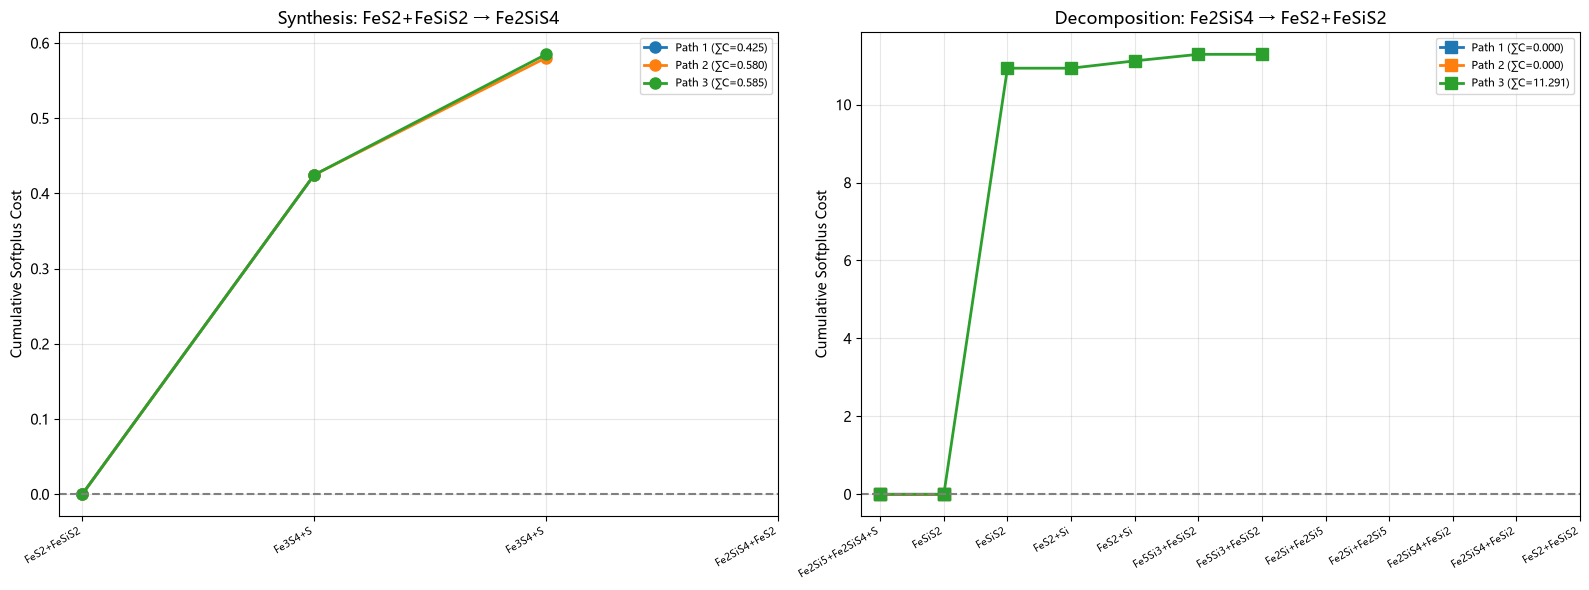

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Synthesis paths ---
ax = axes[0]
labels_syn = []  # init outside loop for empty ksp_paths
for rank, (cost, path) in enumerate(ksp_paths[:3]):
    labels_syn = []
    for n in path:
        if n >= 0:
            labels_syn.append(G.nodes[n].get("label", str(n)))
    rxns_p, costs_p, dgs_p = extract_pathway(G, path)
    cum = np.cumsum([0] + costs_p)
    ax.plot(range(len(cum)), cum, "-o", lw=2, ms=8,
            label=f"Path {rank+1} (∑C={cost:.3f})")
ax.axhline(0, color="gray", ls="--")
if labels_syn:
    ax.set_xticks(range(len(labels_syn)))
    ax.set_xticklabels(labels_syn, fontsize=7, rotation=30, ha="right")
ax.set_ylabel("Cumulative Softplus Cost")
ax.set_title("Synthesis: " + "+".join(PRECURSOR_FORMULAS) + " → " + TARGET_FORMULA)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Decomposition paths ---
ax = axes[1]
labels_dec = []  # init outside loop
for rank, (cost, path) in enumerate(ksp_dec[:3]):
    labels_dec = []
    for n in path:
        if n >= 0:
            labels_dec.append(G_dec.nodes[n].get("label", str(n)))
    rxns_p, costs_p, dgs_p = extract_pathway(G_dec, path)
    cum = np.cumsum([0] + costs_p)
    ax.plot(range(len(cum)), cum, "-s", lw=2, ms=8,
            label=f"Path {rank+1} (∑C={cost:.3f})")
ax.axhline(0, color="gray", ls="--")
if labels_dec:
    ax.set_xticks(range(len(labels_dec)))
    ax.set_xticklabels(labels_dec, fontsize=7, rotation=30, ha="right")
ax.set_ylabel("Cumulative Softplus Cost")
ax.set_title("Decomposition: " + TARGET_FORMULA + " → " + "+".join(PRECURSOR_FORMULAS))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 11. 汇总输出与报告保存


In [11]:
print("=" * 70)
print(f"  Thermodynamic Reaction Network + KSP Evaluation")
print(f"  Based on McDermott et al., Nat. Commun. 2021")
print(f"  Target: {TARGET_FORMULA} ({target_id})")
print(f"  Precursors: {PRECURSOR_FORMULAS}")
print(f"  T_synthesis: {T_SYNTHESIS} K")
print(f"  Cost function: C = ln(1 + (273/{T_SYNTHESIS}) * exp(Δg))")
print("=" * 70)

print(f"\n  Chemical system: {els}")
print(f"  Phase filtering: e_above_hull < {E_ABOVE_HULL_CUTOFF} eV/atom → {len(formulas_full)} phases")
print(f"  Reaction edges: {N_EDGES} unique")
print(f"  Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ---- Synthesis ----
if len(ksp_paths) > 0:
    best_syn = ksp_paths[0]
    rxns_best, costs_best, dgs_best = extract_pathway(G, best_syn[1])
    print(f"\n## Best synthesis pathway (total_cost={best_syn[0]:.4f})")
    print("| 步骤 | 反应方程式 | ΔG (eV/atom) | 步骤成本 |")
    print("| :---: | :--- | :---: | :---: |")
    for j, rxn in enumerate(rxns_best):
        print(f"| {j+1} | {rxn} | {dgs_best[j]:+.3f} | {costs_best[j]:.3f} |")
    print()

# ---- Decomposition ----
if len(ksp_dec) > 0:
    best_dec = ksp_dec[0]
    rxns_dec, costs_dec, dgs_dec = extract_pathway(G_dec, best_dec[1])
    print(f"\n## Best decomposition pathway (total_cost={best_dec[0]:.4f})")
    print("| 步骤 | 反应方程式 | ΔG (eV/atom) | 步骤成本 |")
    print("| :---: | :--- | :---: | :---: |")
    for j, rxn in enumerate(rxns_dec):
        print(f"| {j+1} | {rxn} | {dgs_dec[j]:+.3f} | {costs_dec[j]:.3f} |")
    print()

# ---- Save report ----
with open("kinetics_network_v2_report.md", "w", encoding="utf-8") as f:
    pfx = " + ".join(PRECURSOR_FORMULAS)
    f.write(f"# {TARGET_FORMULA} Thermodynamic Reaction Network (v2)\n\n")
    f.write(f"**Method**: McDermott et al. Nat. Commun. 2021 graph-based approach\n")
    f.write(f"**Target**: {TARGET_FORMULA} ({target_id})\n")
    f.write(f"**Precursors**: {pfx}\n")
    f.write(f"**T_synthesis**: {T_SYNTHESIS} K\n")
    f.write(f"**Cost function**: C = ln(1 + (273/{T_SYNTHESIS}) * exp(Δg))\n\n")
    f.write("## Synthesis Pathways\n\n")
    f.write("| 路径 | 总成本 | 步骤 | 反应方程式 | ΔG (eV/atom) | 步骤成本 |\n")
    f.write("| :---: | :---: | :---: | :--- | :---: | :---: |\n")
    for rank, (cost, path) in enumerate(ksp_paths[:5]):
        rxns_p, costs_p, dgs_p = extract_pathway(G, path)
        for j, rxn in enumerate(rxns_p):
            f.write(f"| {rank+1} | {cost:.3f} | {j+1} | {rxn} | {dgs_p[j]:+.3f} | {costs_p[j]:.3f} |\n")
    f.write("\n")
    f.write("## Decomposition Pathways\n\n")
    f.write("| 路径 | 总成本 | 步骤 | 反应方程式 | ΔG (eV/atom) | 步骤成本 |\n")
    f.write("| :---: | :---: | :---: | :--- | :---: | :---: |\n")
    for rank, (cost, path) in enumerate(ksp_dec[:3]):
        rxns_p, costs_p, dgs_p = extract_pathway(G_dec, path)
        for j, rxn in enumerate(rxns_p):
            f.write(f"| {rank+1} | {cost:.3f} | {j+1} | {rxn} | {dgs_p[j]:+.3f} | {costs_p[j]:.3f} |\n")
    f.write("\n")
    # --- Crossover + Linear Combination
    if "crossover_edge_costs" in dir() and "cross_list" in dir() and len(cross_list) > 0:
        f.write("## Crossover Reactions + Linear Combination\n\n")
        f.write("| 步骤 | 反应方程式 | ΔG (eV/atom) | 步骤成本 |\n")
        f.write("| :---: | :--- | :---: | :---: |\n")
        for j, ((rk, pk), (cost, dg, rxn)) in enumerate(cross_list):
            f.write(f"| {j+1} | {rxn} | {dg:+.3f} | {cost:.3f} |\n")
        f.write("\n")
        # Balanced pathway combinations (official solver output)
        if "balanced_paths" in dir() and balanced_paths:
            f.write("## Balanced Pathway Combinations\n\n")
            for pi, (m_sub, combo, wc, res) in enumerate(balanced_paths[:5]):
                f.write(f"### Path {pi+1} (weighted cost = {wc:.4f}, residual = {res:.6f})\n\n")
                f.write("| 步骤 | 反应方程式 | ΔG (eV/atom) | 成本 | 倍数 |\n")
                f.write("| :---: | :--- | :---: | :---: | :---: |\n")
                for j, (idx, mj) in enumerate(zip(combo, m_sub)):
                    (rk, pk), (cost, dg, rxn) = cross_list[idx]
                    f.write(f"| {j+1} | {rxn} | {dg:+.3f} | {cost:.3f} | {mj:.3f} |\n")
                f.write("\n")

print("\nkinetics_network_v2_report.md saved")


  Thermodynamic Reaction Network + KSP Evaluation
  Based on McDermott et al., Nat. Commun. 2021
  Target: Fe2SiS4 ('identifier' 'mp-aaackkso', 'suffix' 'GGA', 'separator' '-', '@module' 'emmet.core.types.pymatgen_types.computed_entries_adapter', '@class' 'EntryID', '@version' None)
  Precursors: ['FeS2', 'FeSiS2']
  T_synthesis: 900.0 K
  Cost function: C = ln(1 + (273/900.0) * exp(Δg))

  Chemical system: ['Fe', 'Si', 'S']
  Phase filtering: e_above_hull < 0.5 eV/atom → 20 phases
  Reaction edges: 4285 unique
  Graph: 1191 nodes, 4874 edges

## Best synthesis pathway (total_cost=0.4246)
| 步骤 | 反应方程式 | ΔG (eV/atom) | 步骤成本 |
| :---: | :--- | :---: | :---: |
| 1 | FeS2 -> 0.6667 S + 0.3333 Fe3S4 | +0.556 | 0.425 |


## Best decomposition pathway (total_cost=0.0000)
| 步骤 | 反应方程式 | ΔG (eV/atom) | 步骤成本 |
| :---: | :--- | :---: | :---: |
| 1 | 0.5 S + 0.125 Fe2Si5 + 0.375 Fe2SiS4 -> FeSiS2 | -12.774 | 0.000 |


kinetics_network_v2_report.md saved


## 12. 0K 参照报告

使用方案1的 0K DFT 能量（不经 Gibbs 温度修正）构建反应网络，
输出至 `kinetics_network_v2_report_0k.md`，便于与 Gibbs 修正结果对比。


In [12]:
# ===== 0K 参照报告 ===== 使用 scheme1 数据重新运行核心管道
scheme1_path = os.path.join("..", "方案1", "scheme1_export.json")
if os.path.exists(scheme1_path):
    print("加载方案1 0K 条目...")
    with open(scheme1_path, "r", encoding="utf-8") as f:
        s1 = json.load(f, cls=MontyDecoder)
    entries_0k = s1["entries"]
    for e in entries_0k:
        if not isinstance(getattr(e, "entry_id", None), str):
            e.entry_id = str(getattr(e, "entry_id", e.composition.reduced_formula))
    entries_mp0k = [e for e in entries_0k if getattr(e, "data", {}).get("source", "") not in ("M3GNet", "MACE-MP-0")]
    entries_ml0k = [e for e in entries_0k if getattr(e, "data", {}).get("source", "") in ("M3GNet", "MACE-MP-0")]
    scheme = MaterialsProjectDFTMixingScheme()
    entries_mp0k = scheme.process_entries(entries_mp0k)
    entries_0k = entries_mp0k + entries_ml0k
    print(f"   {len(entries_0k)} entries loaded (0K)")

    # --- Phase filtering (0K hull) ---
    pd0 = PhaseDiagram(entries_0k)
    _filtered = []
    for e in entries_0k:
        h = pd0.get_e_above_hull(e)
        if h is not None and h < E_ABOVE_HULL_CUTOFF:
            e.data["e_above_hull"] = h
            _filtered.append(e)
    _gs = {}
    for e in _filtered:
        rf = e.composition.reduced_formula
        if rf not in _gs or e.energy_per_atom < _gs[rf].energy_per_atom:
            _gs[rf] = e
    # Force target into filtered (0K may be above cutoff)
    if TARGET_FORMULA not in _gs:
        _tgt = [e for e in entries_0k if e.composition.reduced_formula == TARGET_FORMULA]
        if _tgt:
            _bt = min(_tgt, key=lambda e: e.energy_per_atom)
            _bt.data["e_above_hull"] = pd0.get_e_above_hull(_bt) or 999
            _gs[TARGET_FORMULA] = _bt
            _filtered.append(_bt)
    _filtered = list(_gs.values())
    _entry_map = {e.composition.reduced_formula: e for e in _filtered}

    # --- Precursors (0K decomposition) ---
    _target_comp = _entry_map[TARGET_FORMULA].composition
    _decomp = pd0.get_decomposition(_target_comp)
    if len(_decomp) <= 1:
        _entries_no_tgt = [e for e in entries_0k if e.composition.reduced_formula != TARGET_FORMULA]
        _decomp = PhaseDiagram(_entries_no_tgt).get_decomposition(_target_comp)
    _precursors_0k = [pd_e.composition.reduced_formula for pd_e in _decomp.keys()]
    print(f"   0K Precursors: {_precursors_0k}")

    # --- Reactions ---
    _rxns_raw = enumerate_reactions(_filtered, MAX_REACTANTS, verbose=False)
    _rxns = deduplicate_by_formula(_rxns_raw)
    # proximity filter
    _pset = frozenset(_precursors_0k)
    _rf = []
    for rxn in _rxns:
        rr = frozenset(e.composition.reduced_formula for e in rxn.reactant_entries)
        pp = frozenset(e.composition.reduced_formula for e in rxn.product_entries)
        if (rr & _pset) or (TARGET_FORMULA in pp) or (TARGET_FORMULA in rr):
            _rf.append(rxn)
    _rxns = _rf
    print(f"   0K Reaction edges: {len(_rxns)}")

    # --- Cost computation (T=1073K for 0K baseline) ---
    _edge_costs = {}
    for rxn in _rxns:
        rk = frozenset(e.composition.reduced_formula for e in rxn.reactant_entries)
        pk = frozenset(e.composition.reduced_formula for e in rxn.product_entries)
        _edge_costs[(rk, pk)] = (softplus_cost(rxn.energy_per_atom, T=1073.0), rxn.energy_per_atom)

    # --- Graph ---
    _G, _r_nodes, _p_nodes = build_thermo_graph(_rxns, _edge_costs)
    _SOURCE, _SINK = add_source_sink(_G, _r_nodes, _p_nodes, _precursors_0k, TARGET_FORMULA)

    # --- KSP ---
    _ksp_raw = yen_ksp(_G, _SOURCE, _SINK, K=K_SHORTEST)
    _ksp = [(tc, p) for tc, p in _ksp_raw if len(extract_pathway(_G, p)[0]) > 0]
    print(f"   0K KSP: {len(_ksp)} synthesis paths")

    # --- Decomposition ---
    _Gd = _G.copy()
    for old in [-1, -2]:
        if old in _Gd.nodes(): _Gd.remove_node(old)
    _SD, _SK = -1, -2
    _Gd.add_node(_SD, ntype="Source", label="SD"); _Gd.add_node(_SK, ntype="Sink", label="SK")
    for r_key, r_idx in _r_nodes.items():
        if TARGET_FORMULA in r_key: _Gd.add_edge(_SD, r_idx, edge_type="precursor_edge", cost=0.0, dg=0.0)
    _ps = set(_precursors_0k)
    for p_key, p_idx in _p_nodes.items():
        if p_key.issubset(_ps): _Gd.add_edge(p_idx, _SK, edge_type="target_edge", cost=0.0, dg=0.0)
    _kd_raw = yen_ksp(_Gd, _SD, _SK, K=K_SHORTEST)
    _kd = [(tc, p) for tc, p in _kd_raw if len(extract_pathway(_Gd, p)[0]) > 0]
    print(f"   0K Decomp: {len(_kd)} paths")

    # --- Save 0K report ---
    _target_id = str(getattr(_entry_map[TARGET_FORMULA], "entry_id", TARGET_FORMULA))
    with open("kinetics_network_v2_report_0k.md", "w", encoding="utf-8") as f:
        f.write(f"# {TARGET_FORMULA} Reaction Network (0K DFT)\n\n")
        f.write(f"**Target**: {TARGET_FORMULA} ({_target_id[:30]})\n")
        f.write(f"**Precursors**: {" + ".join(_precursors_0k)}\n")
        f.write(f"**T_synthesis**: 1073 K (0K DFT, no Gibbs correction)\n")
        f.write(f"**Cost function**: C = ln(1 + (273/1073) * exp(dG))\n\n")
        f.write("## Synthesis Pathways\n\n")
        f.write("| Path | Total Cost | Step | Reaction | dG (eV/atom) | Step Cost |\n")
        f.write("| :---: | :---: | :---: | :--- | :---: | :---: |\n")
        for rank, (cost, path) in enumerate(_ksp[:5]):
            rxns_p, costs_p, dgs_p = extract_pathway(_G, path)
            for j, rxn in enumerate(rxns_p):
                f.write(f"| {rank+1} | {cost:.3f} | {j+1} | {rxn} | {dgs_p[j]:+.3f} | {costs_p[j]:.3f} |\n")
        f.write("\n## Decomposition Pathways\n\n")
        f.write("| Path | Total Cost | Step | Reaction | dG (eV/atom) | Step Cost |\n")
        f.write("| :---: | :---: | :---: | :--- | :---: | :---: |\n")
        for rank, (cost, path) in enumerate(_kd[:5]):
            rxns_p, costs_p, dgs_p = extract_pathway(_Gd, path)
            for j, rxn in enumerate(rxns_p):
                f.write(f"| {rank+1} | {cost:.3f} | {j+1} | {rxn} | {dgs_p[j]:+.3f} | {costs_p[j]:.3f} |\n")
    print("\nkinetics_network_v2_report_0k.md saved")
else:
    print("scheme1_export.json not found — skip 0K report")


加载方案1 0K 条目...
   143 entries loaded (0K)
   0K Precursors: ['FeS2', 'FeSiS2']
   0K Reaction edges: 10601
Graph: 2271 nodes (1136Rx,1135Pd), 11507 edges (10601rxn+906lb)
  Source→3Rx, 155Pd→Sink
   0K KSP: 52 synthesis paths
   0K Decomp: 88 paths

kinetics_network_v2_report_0k.md saved
